# Harper-Hofstadter Flux Sweep


**Purpose.** Sweep magnetic flux in a finite square-lattice tight-binding model to produce Hofstadter-style spectra and connectivity checks.


**Lattice model.** In Landau gauge, the Harper-Hofstadter Hamiltonian has real horizontal hoppings and vertical hoppings with Peierls phase $e^{2\pi i f x}$, so $H=-t\sum_{\langle i,j\rangle}e^{iA_{ij}}|i\rangle\langle j|+h.c.$.


**Variables.** $N_r$ and $N_c$ are set by `n_rows` and `n_cols`; $t$ is set by `hopping`; $f$ is the flux per plaquette in flux-quantum units and is set by `flux`; $x$ is the column index; `periodic_x` and `periodic_y` select wrapped boundaries.


**Outputs.** The notebook prints model metadata, plots a fixed-flux spectrum and lattice graph, and sweeps flux to show the spectrum versus $f$.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.geometry import square_lattice_positions
from quantum_lattice_models.models import harper_hofstadter_square_lattice
from quantum_lattice_models.plotting import (
    plot_hofstadter_butterfly,
    plot_lattice_graph,
    plot_spectrum,
)

In [2]:
n_rows = 4
n_cols = 4
flux = 0.25
H = harper_hofstadter_square_lattice(n_rows=n_rows, n_cols=n_cols, hopping=1.0, flux=flux)
print("Harper-Hofstadter model")
print(f"  matrix shape: {H.shape}")
print(f"  lattice:      {n_rows} x {n_cols}")
print(f"  hopping:      {H.metadata['hopping']:.2f}")
print(f"  flux:         {H.metadata['flux']:.2f}")

Harper-Hofstadter model
  matrix shape: (16, 16)
  lattice:      4 x 4
  hopping:      1.00
  flux:         0.25


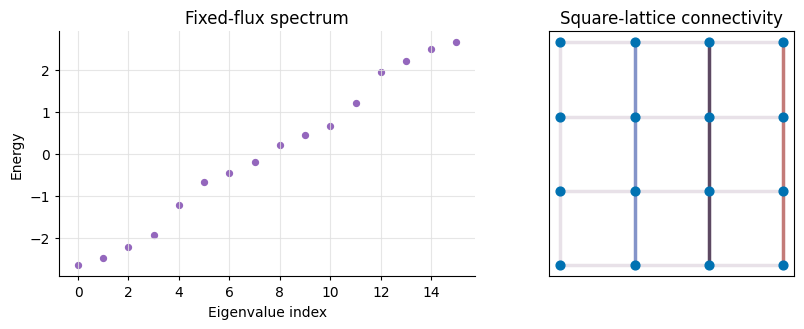

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_spectrum(H, ax=axes[0], s=18, color="tab:purple")
axes[0].set_title("Fixed-flux spectrum")
plot_lattice_graph(H, square_lattice_positions(n_rows, n_cols), ax=axes[1], node_size=40)
axes[1].set_title("Square-lattice connectivity")
fig.tight_layout()

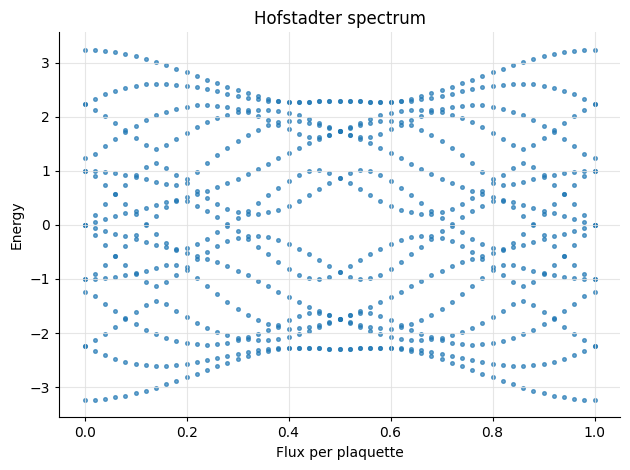

In [4]:
fluxes = np.linspace(0.0, 1.0, 51)
ax = plot_hofstadter_butterfly(
    lambda phi: harper_hofstadter_square_lattice(n_rows=n_rows, n_cols=n_cols, flux=phi),
    fluxes,
    s=7,
    color="tab:blue",
)
ax.figure.tight_layout()